# FLOWCHART

Dataset :  DeteksiSarkasme.json

📚 1. Instalasi dan Impor Library


In [4]:
!pip install -q keras-tuner

In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report


📥 2. Membaca dan Memproses Data

In [7]:
!wget -O DeteksiSarkasme.json https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/07.%20Week%207/Datasets/DeteksiSarkasme.json


--2025-04-20 02:13:45--  https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/07.%20Week%207/Datasets/DeteksiSarkasme.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5616830 (5.4M) [text/plain]
Saving to: ‘DeteksiSarkasme.json’

DeteksiSarkasme.jso 100%[===================>]   5.36M  --.-KB/s    in 0.05s   

2025-04-20 02:13:45 (106 MB/s) - ‘DeteksiSarkasme.json’ saved [5616830/5616830]



In [9]:
import json
import pandas as pd

# Membaca JSONL: satu baris = satu objek JSON
with open('DeteksiSarkasme.json', 'r') as f:
    data = [json.loads(line) for line in f]

# Konversi ke DataFrame
df = pd.DataFrame(data)

# Tampilkan beberapa baris pertama
df.head()


,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [10]:
# Memisahkan fitur dan label
texts = df['headline'].values
labels = df['is_sarcastic'].values


🔢 3. Tokenisasi dan Padding

In [11]:
# Menentukan jumlah kata maksimum dan panjang maksimum
max_words = 10000
max_len = 100

# Tokenisasi teks
tokenizer = keras.preprocessing.text.Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

# Padding sequences
padded_sequences = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_len, padding='post')

# Membagi data menjadi training dan testing
x_train, x_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)


🧠 4. Membangun Model BiRNN dengan Hyperparameter Tuning

In [12]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Embedding(input_dim=max_words,
                               output_dim=hp.Choice('embedding_dim', [64, 128, 256]),
                               input_length=max_len))
    model.add(layers.Bidirectional(layers.LSTM(units=hp.Int('lstm_units', min_value=32, max_value=128, step=32),
                                               return_sequences=False)))
    model.add(layers.Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(layers.Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
                           activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=keras.optimizers.Adam(
                    hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


🔍 5. Hyperparameter Tuning dengan Keras Tuner

In [13]:
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='sarcasm_detection')

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early])


Trial 30 Complete [00h 00m 41s]
val_accuracy: 0.8341132402420044

Best val_accuracy So Far: 0.8652316331863403
Total elapsed time: 00h 15m 27s


🏆 6. Training Model

In [21]:
# Mendapatkan hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Membangun model dengan hyperparameter terbaik
model = tuner.hypermodel.build(best_hps)

# Melatih model
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early])


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


535/535 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7282 - loss: 0.5013 - val_accuracy: 0.8582 - val_loss: 0.3176
Epoch 2/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9280 - loss: 0.1852 - val_accuracy: 0.8570 - val_loss: 0.3462
Epoch 3/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9684 - loss: 0.0901 - val_accuracy: 0.8421 - val_loss: 0.4503
Epoch 4/10
535/535 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9852 - loss: 0.0445 - val_accuracy: 0.8400 - val_loss: 0.5757


📊 7. Evaluasi Model

In [22]:
# Evaluasi pada data training
train_probs = model.predict(x_train)
train_preds = (train_probs > 0.5).astype("int32")
train_accuracy = accuracy_score(y_train, train_preds)
print(f"✅ Akurasi Training Set: {train_accuracy * 100:.2f}%")

# Evaluasi pada data testing
test_probs = model.predict(x_test)
test_preds = (test_probs > 0.5).astype("int32")
test_accuracy = accuracy_score(y_test, test_preds)
print(f"✅ Akurasi Testing Set: {test_accuracy * 100:.2f}%")

# Metrik evaluasi lainnya
precision = precision_score(y_test, test_preds)
recall = recall_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds)
auc = roc_auc_score(y_test, test_probs)

print(f"🎯 Presisi : {precision * 100:.2f}%")
print(f"🎯 Recall  : {recall * 100:.2f}%")
print(f"🎯 F1-Score: {f1 * 100:.2f}%")
print(f"🎯 AUC     : {auc * 100:.2f}%")


668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
✅ Akurasi Training Set: 96.34%
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
✅ Akurasi Testing Set: 84.03%
🎯 Presisi : 82.84%
🎯 Recall  : 80.26%
🎯 F1-Score: 81.53%
🎯 AUC     : 91.69%



📋 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      2996
           1       0.83      0.80      0.82      2346

    accuracy                           0.84      5342
   macro avg       0.84      0.84      0.84      5342
weighted avg       0.84      0.84      0.84      5342



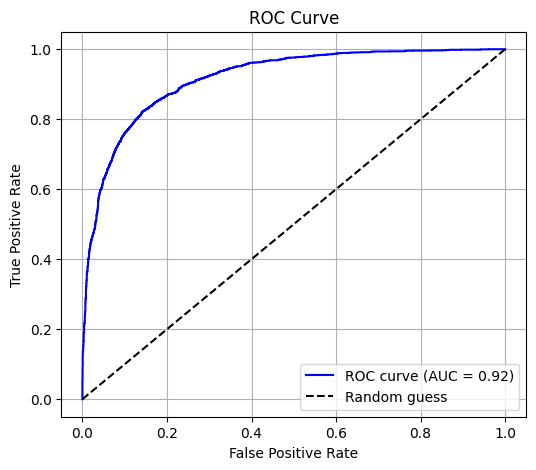

In [23]:
# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, test_preds))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})", color="blue")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

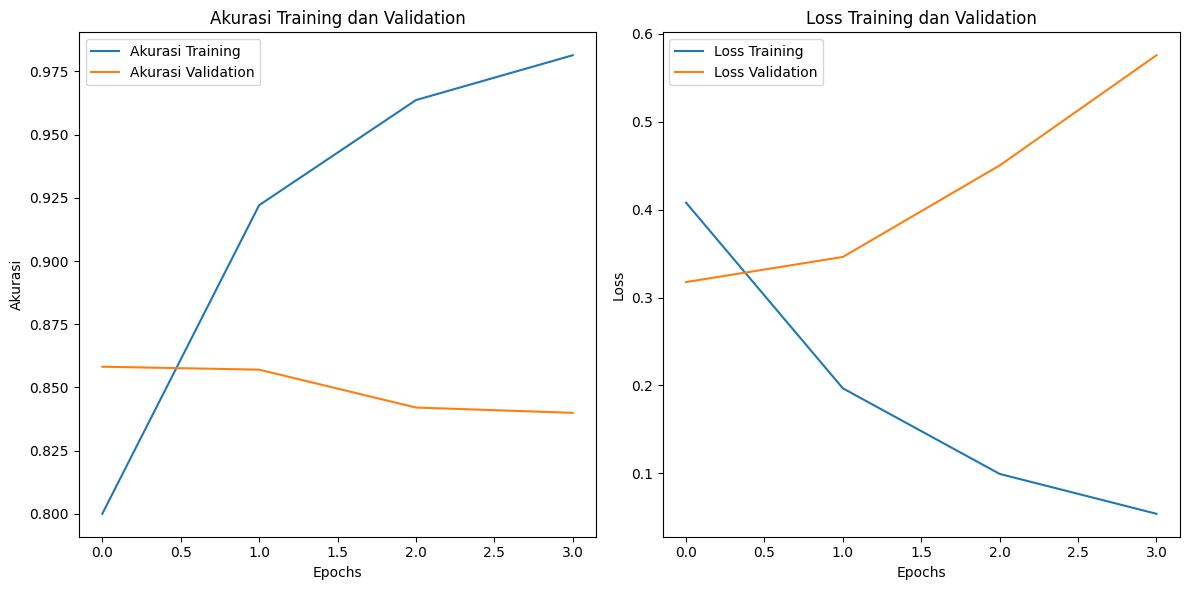

In [24]:
import matplotlib.pyplot as plt

# Visualisasi Akurasi
plt.figure(figsize=(12, 6))

# Plot akurasi training
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validation')
plt.title('Akurasi Training dan Validation')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend()

# Plot loss training
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.title('Loss Training dan Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
